<center><h1>Soundalgekar_Abhishek_HW2</h1></center>
<br>
<br>

Name: Abhishek Soundalgekar
<br>
Github Username: ABHISHEKSOUNDALGEKAR
<br>
USC ID: 2089011000

***

## 1. Combined Cycle Power Plant Data Set. ##

### 1.(a) Download the Combined Cycle Power Plant data ###

#### Package import. ####
please restart the kernel and run all cells in case a particular cell is run and an error pops up. 

In [1]:
pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import statsmodels.formula.api as smf
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from statsmodels.formula.api import ols
from statsmodels.graphics.regressionplots import influence_plot
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

### Get the Cycle Power Plant Data Set ###

In [3]:
file_path = r"../data/CCPP/Folds5x2_pp.xlsx"
df = pd.read_excel(file_path)
print(df)
df.columns = ['AT', 'V', 'AP', 'RH', 'PE']
display(df.head())
print("Dataset Dimensions:", df.shape)

         AT      V       AP     RH      PE
0     14.96  41.76  1024.07  73.17  463.26
1     25.18  62.96  1020.04  59.08  444.37
2      5.11  39.40  1012.16  92.14  488.56
3     20.86  57.32  1010.24  76.64  446.48
4     10.82  37.50  1009.23  96.62  473.90
...     ...    ...      ...    ...     ...
9563  16.65  49.69  1014.01  91.00  460.03
9564  13.19  39.18  1023.67  66.78  469.62
9565  31.32  74.33  1012.92  36.48  429.57
9566  24.48  69.45  1013.86  62.39  435.74
9567  21.60  62.52  1017.23  67.87  453.28

[9568 rows x 5 columns]


,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


Dataset Dimensions: (9568, 5)


***

## 1. (b) Exploring the data: ##

### 1. (b) i] How many rows are in this data set? How many columns? What do the rows and columns represent? ###

In [4]:
print(f"Total Rows: {df.shape[0]:,}")
print(f"Total columns: {df.shape[1]}")
print("\nThe Data Represents:")
print(f"Hourly observations is represented by the Rows.\n")
print(f"Variables are represented by the Columns:\n{', '.join(df.columns.tolist())}\n")
print(f"The columns are Ambient Temperature, Exhaust Vacuum, Ambient Pressure, Relative Humidity and Energy output.\nEnergy output is the target variable (dependent variable) and the others are the independent variables. The 9568 rows are observations.")

Total Rows: 9,568
Total columns: 5

The Data Represents:
Hourly observations is represented by the Rows.

Variables are represented by the Columns:
AT, V, AP, RH, PE

The columns are Ambient Temperature, Exhaust Vacuum, Ambient Pressure, Relative Humidity and Energy output.
Energy output is the target variable (dependent variable) and the others are the independent variables. The 9568 rows are observations.


### 1. (b) ii] Make pairwise scatterplots of all the varianbles in the data set including the predictors (independent variables) with the dependent variable. Describe your findings. ###

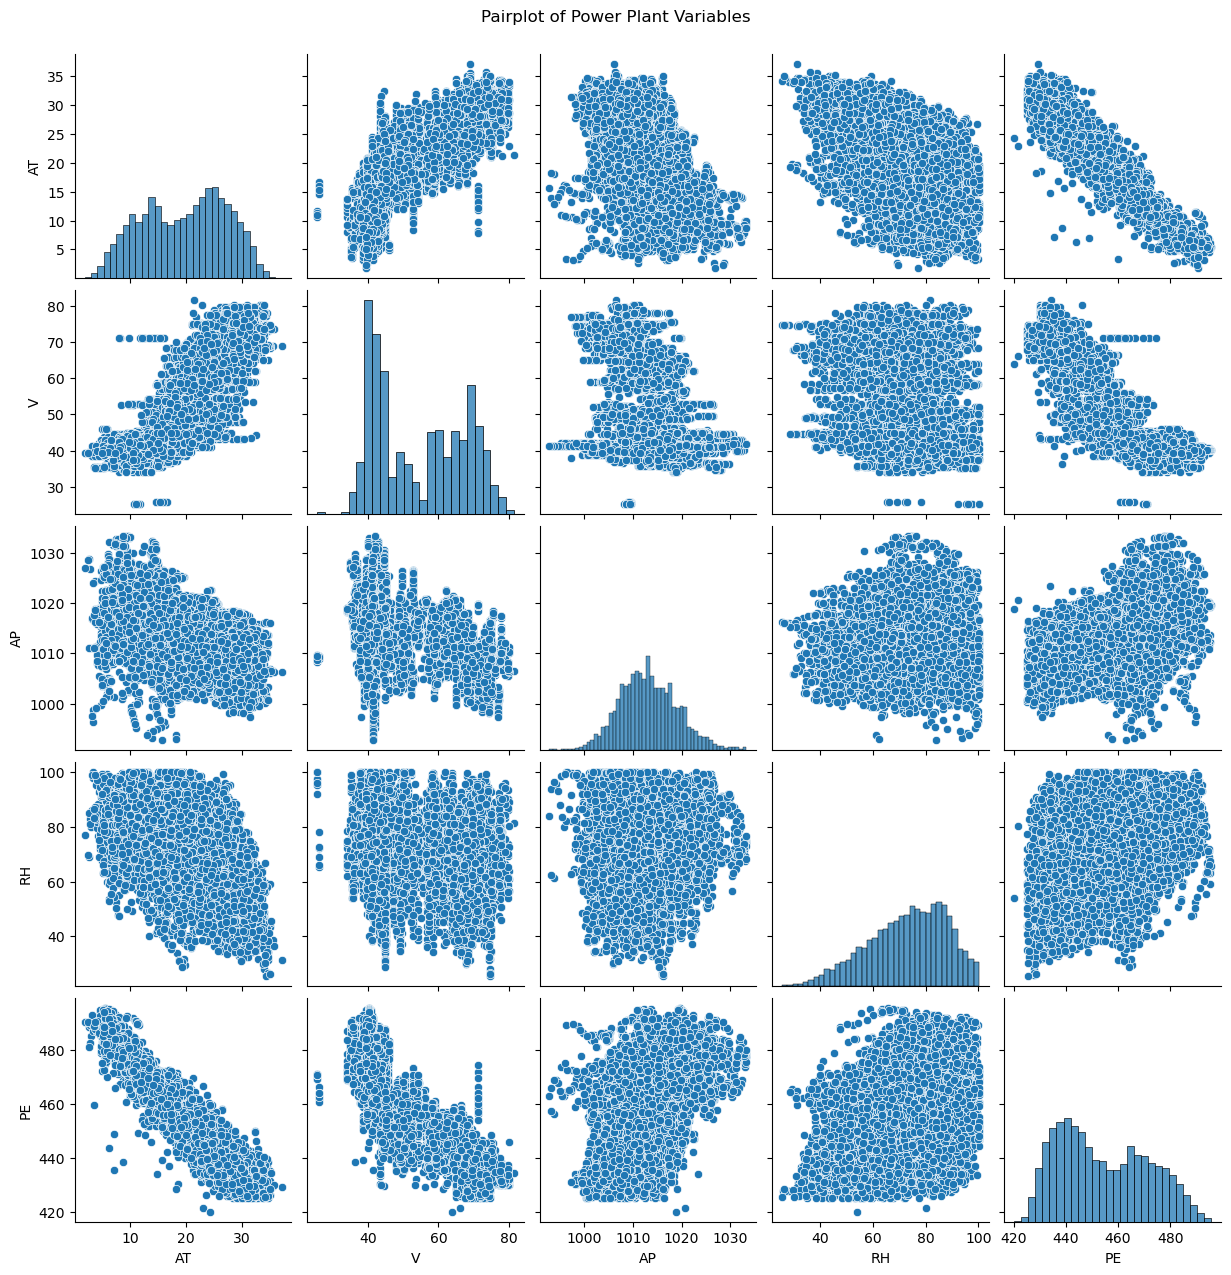

In [5]:
sns.pairplot(data=df)
plt.suptitle("Pairplot of Power Plant Variables", y=1.02)
plt.show()

Based on the pairwise scatterplots between each predictor and the net energy output (PE):

* **Ambient Temperature (AT):** There is a clear negative trend - higher temperatures are consistently associated with lower power output.  The points fall roughly along a downward‐sloping line, suggesting a strong inverse linear relationship with very little scatter around the trend.
* **Exhaust Vacuum (V):** Similarly, increases in vacuum correspond to decreases in energy output. The relationship is almost as tight as with temperature, indicating that vacuum is a key driver of PE.
* **Ambient Pressure (AP):** The scatter is much more diffuse - no obvious upward or downward slope. This implies that pressure fluctuations in the observed range have little systematic effect on power output; any relationship is very weak if it exists at all.
* **Relative Humidity (RH):** The cloud of points shows a gentle downward tilt, but with more noise than AT or V.  This suggests a modest negative association—humidity may play a role, but other factors dominate its effect on PE.

In summary, AT and V exhibit the strongest, almost linear, negative associations with output; RH shows a mild negative trend; and AP appears largely unrelated.


### 1. (b) iii] What are the mean, the median, range, first and third quartiles, and in-terquartile ranges of each of the variables in the dataset? Summarize them in a table. ###

In [6]:
summary = (
    df.describe().T.assign(
          Range=lambda d: d["max"] - d["min"],
          IQR=lambda d: d["75%"] - d["25%"]
      )
      [["mean", "50%", "Range", "25%", "75%", "IQR", "min", "max"]]
      .rename(columns={
          "mean": "Mean",
          "50%": "Median",
          "25%": "Q1",
          "75%": "Q3",
          "min": "Min",
          "max": "Max"
      })
)
print(summary)

           Mean    Median  Range         Q1       Q3      IQR     Min      Max
AT    19.651231    20.345  35.30    13.5100    25.72  12.2100    1.81    37.11
V     54.305804    52.080  56.20    41.7400    66.54  24.8000   25.36    81.56
AP  1013.259078  1012.940  40.41  1009.1000  1017.26   8.1600  992.89  1033.30
RH    73.308978    74.975  74.60    63.3275    84.83  21.5025   25.56   100.16
PE   454.365009   451.550  75.50   439.7500   468.43  28.6800  420.26   495.76


***

## 1. (c) Simple Linear Regression ##

In [7]:
df = pd.read_excel(r"../data/CCPP/Folds5x2_pp.xlsx")  
df.columns = df.columns.str.strip()  
print(df.columns.tolist())

label_to_col = {
    'Ambient Temperature (AT)': 'AT',
    'Exhaust Vacuum (V)': 'V',
    'Ambient Pressure (AP)': 'AP',
    'Relative Humidity (RH)': 'RH'
}
response_col = 'PE'
response_label = 'Energy Output (PE)'

sns.set(style="darkgrid", palette="muted", font_scale=1.1)


['AT', 'V', 'AP', 'RH', 'PE']


In [8]:
models = {}
rows = []
for name, col in label_to_col.items():
    X = sm.add_constant(df[[col]])
    y = df[response_col]
    fit = sm.OLS(y, X).fit()
    models[col] = fit
    rows.append({
        'Predictor': name,
        'Coef': fit.params[col],
        'P-value': fit.pvalues[col],
        'R²': fit.rsquared
    })
summary = pd.DataFrame(rows)
summary['Significant'] = summary['P-value'] < 0.05
summary.style.format({
    'Coef': '{:+.3f}',
    'P-value': '{:.4f}',
    'R²': '{:.3f}'
})


,Predictor,Coef,P-value,R²,Significant
0,Ambient Temperature (AT),-2.171,0.0000,0.899,True
1,Exhaust Vacuum (V),-1.168,0.0000,0.757,True
2,Ambient Pressure (AP),+1.490,0.0000,0.269,True
3,Relative Humidity (RH),+0.456,0.0000,0.152,True


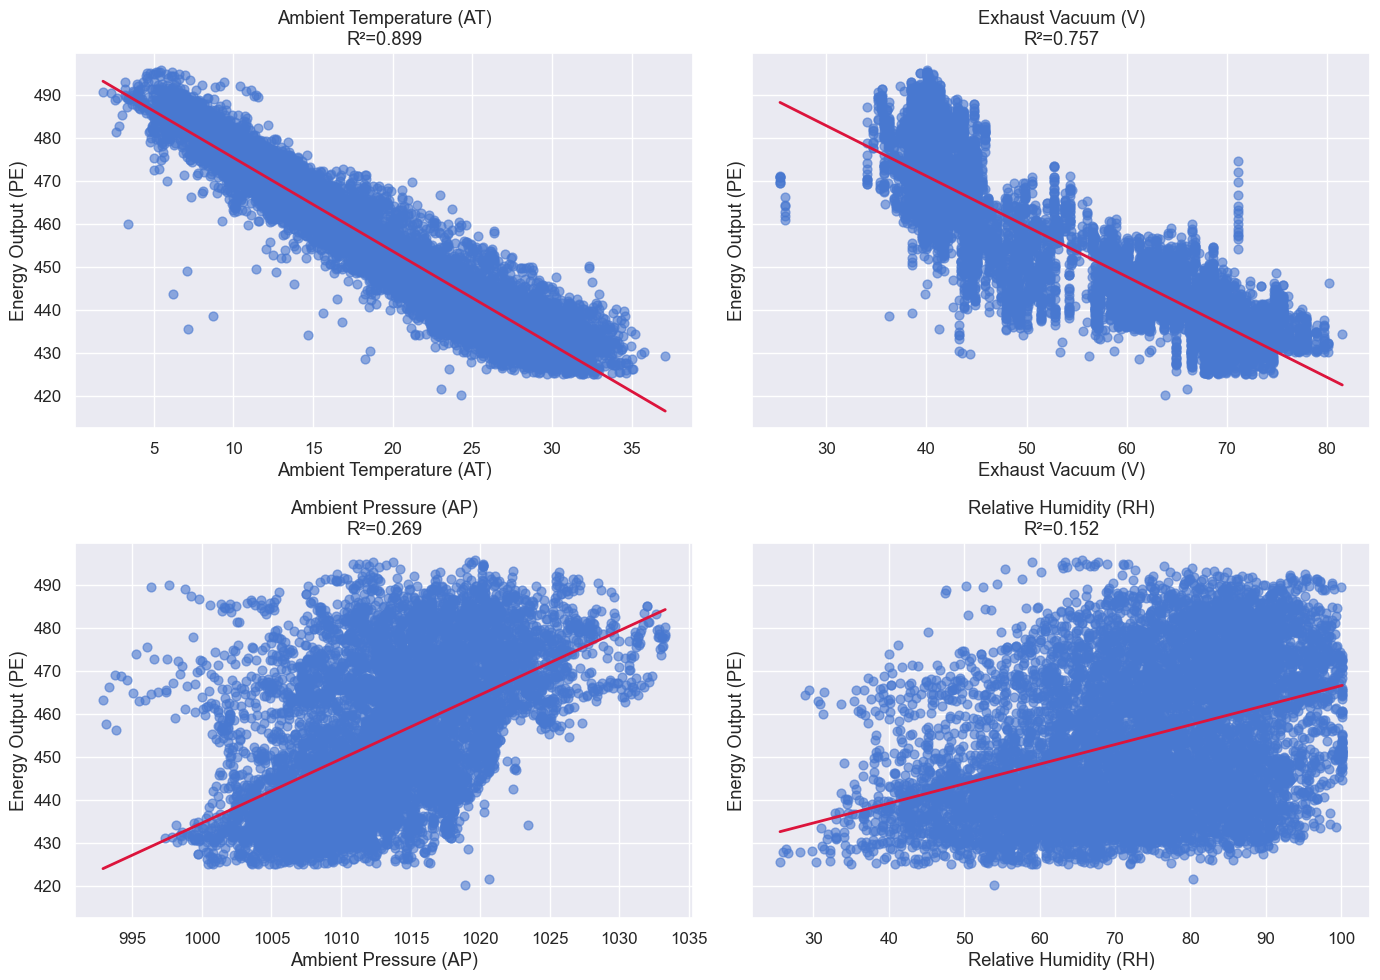

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14,10), sharey=True)
for ax, (name, col) in zip(axes.flatten(), label_to_col.items()):
    sns.regplot(
        x=df[col], y=df[response_col], ax=ax,
        scatter_kws={'alpha':0.6,'s':40},
        line_kws={'color':'crimson','lw':2},
        ci=None
    )
    ax.set_title(f"{name}\nR²={models[col].rsquared:.3f}")
    ax.set_xlabel(name)
    ax.set_ylabel(response_label)
plt.tight_layout()
plt.show()


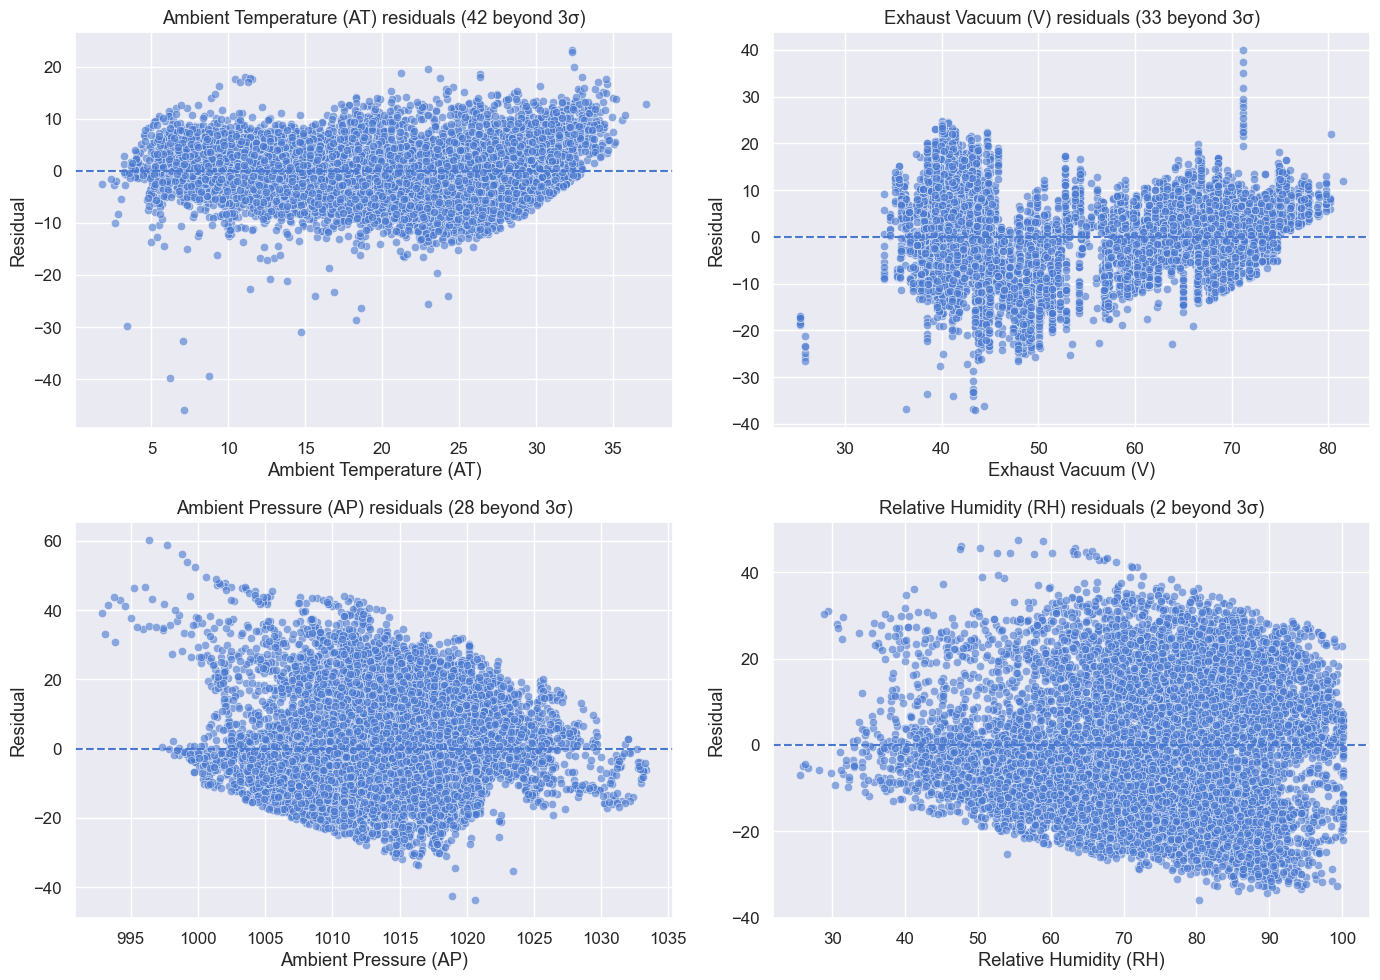

,Predictor,Outliers
0,Ambient Temperature (AT),42
1,Exhaust Vacuum (V),33
2,Ambient Pressure (AP),28
3,Relative Humidity (RH),2


In [10]:
outliers = []
fig, axes = plt.subplots(2, 2, figsize=(14,10))
for ax, (name, col) in zip(axes.flatten(), label_to_col.items()):
    fit = models[col]
    resid = fit.resid
    thresh = 3 * resid.std()
    count = (resid.abs() > thresh).sum()
    outliers.append({'Predictor': name, 'Outliers': int(count)})
    sns.scatterplot(x=df[col], y=resid, ax=ax, alpha=0.6)
    ax.axhline(0, linestyle='--')
    ax.set_title(f"{name} residuals ({count} beyond 3σ)")
    ax.set_xlabel(name)
    ax.set_ylabel("Residual")
plt.tight_layout()
plt.show()

pd.DataFrame(outliers)


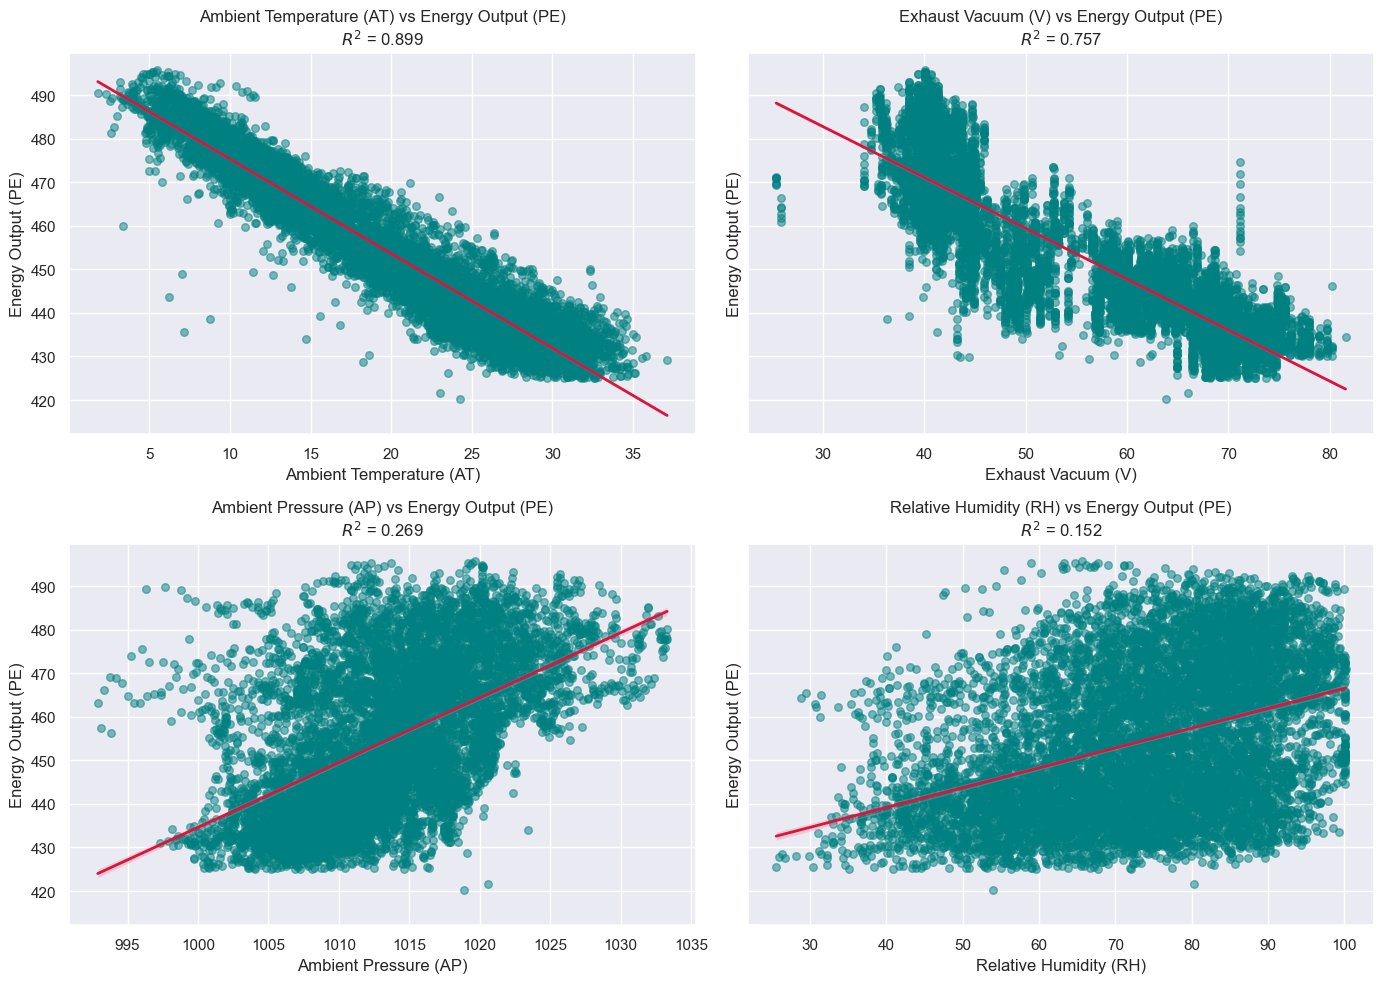


[Statistical Significance]
               Predictor Coefficient P-value Significant
Ambient Temperature (AT)      -2.171  0.0000         Yes
      Exhaust Vacuum (V)      -1.168  0.0000         Yes
   Ambient Pressure (AP)      +1.490  0.0000         Yes
  Relative Humidity (RH)      +0.456  0.0000         Yes

[Outlier Report]
               Predictor  Outliers Recommendation
Ambient Temperature (AT)        42         Review
      Exhaust Vacuum (V)        33         Review
   Ambient Pressure (AP)        28         Review
  Relative Humidity (RH)         2         Review

[RH ~ AT] Adj. R² = 0.294, p-value(AT) = 0.0000

[AP ~ AT] Adj. R² = 0.258, p-value(AT) = 0.0000


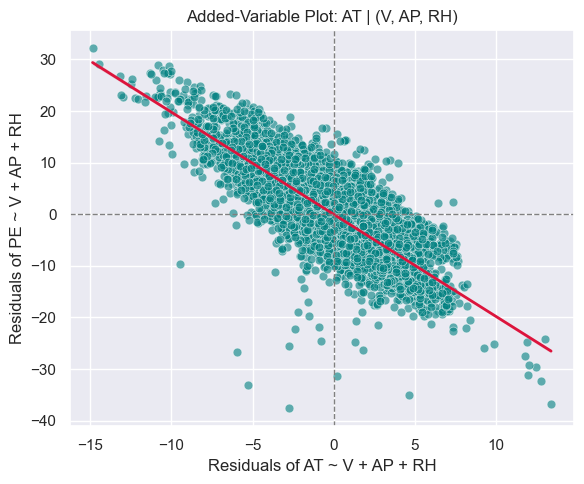


[VIF for Each Predictor]
Variable      VIF
   const 43761.15
      AT     5.98
       V     3.94
      AP     1.45
      RH     1.71


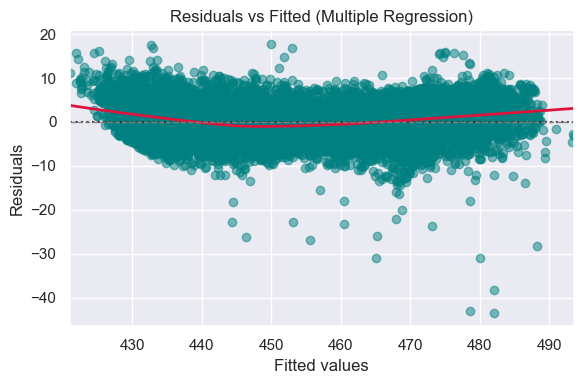

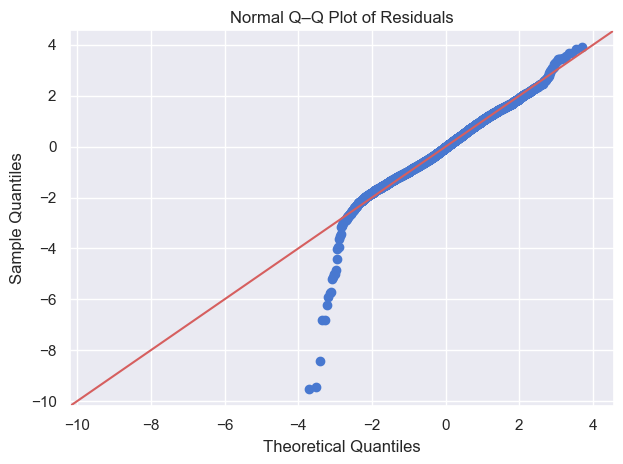

In [11]:
#in short summary:
label_to_col = {
    'Ambient Temperature (AT)': 'AT',
    'Exhaust Vacuum (V)':        'V',
    'Ambient Pressure (AP)':     'AP',
    'Relative Humidity (RH)':    'RH'
}
response_col = 'PE'
response_label = 'Energy Output (PE)'

# Simple regressions, outliers, and scatter/regression plots
models = {}
outlier_counts = {}
sns.set(style="darkgrid", palette="muted", font_scale=1.0)
fig, axes = plt.subplots(2, 2, figsize=(14,10), sharey=True)
axes = axes.flatten()

for ax, (label, col) in zip(axes, label_to_col.items()):
    X = sm.add_constant(df[[col]])    # matrix with intercept
    y = df[response_col]

    fit = sm.OLS(y, X).fit()          # OLS fitted
    models[col] = fit

    # count 3σ outliers
    sigma = fit.resid.std()
    outlier_counts[col] = int((fit.resid.abs() > 3*sigma).sum())

    # scatter + regression line
    sns.regplot(
        x=df[col], y=df[response_col], ax=ax,
        scatter_kws={'alpha':0.5, 's':30, 'color':'teal'},
        line_kws={'color':'crimson', 'lw':2}
    )
    ax.set_title(f"{label} vs {response_label}\n" +
                 r"$R^2$" + f" = {fit.rsquared:.3f}")
    ax.set_xlabel(label)
    ax.set_ylabel(response_label)

plt.tight_layout()
plt.show()

summary_table = pd.DataFrame({
    'Predictor': list(label_to_col.keys()),
    'Coefficient': [models[col].params[col] for col in label_to_col.values()],
    'P-value':     [models[col].pvalues[col] for col in label_to_col.values()]
})
summary_table['Significant'] = summary_table['P-value'] < 0.05

print("\n[Statistical Significance]")
print(
    summary_table
      .to_string(index=False, formatters={
          'Coefficient': '{:+.3f}'.format,
          'P-value':     '{:.4f}'.format,
          'Significant': lambda x: 'Yes' if x else 'No'
      })
)

outlier_df = pd.DataFrame({
    'Predictor':     list(label_to_col.keys()),
    'Outliers':      [outlier_counts[col] for col in label_to_col.values()]
})
outlier_df['Recommendation'] = np.where(outlier_df['Outliers'] > 0, 'Review', 'No action')

print("\n[Outlier Report]")
print(outlier_df.to_string(index=False))

# Collinearity: regress RH & AP on AT
for dep in ['RH', 'AP']:
    m = smf.ols(f"{dep} ~ AT", data=df).fit()
    print(f"\n[{dep} ~ AT] Adj. R² = {m.rsquared_adj:.3f}, p-value(AT) = {m.pvalues['AT']:.4f}")

# variable plot for AT controlling V, AP, RH
resid_AT = smf.ols("AT ~ V + AP + RH", data=df).fit().resid
resid_PE = smf.ols("PE ~ V + AP + RH", data=df).fit().resid

plt.figure(figsize=(6,5))
sns.scatterplot(x=resid_AT, y=resid_PE, color='teal', s=40, alpha=0.6)
sns.regplot(x=resid_AT, y=resid_PE, scatter=False,
            line_kws={'color':'crimson','lw':2})
plt.axhline(0, color='gray', ls='--', lw=1)
plt.axvline(0, color='gray', ls='--', lw=1)
plt.title("Added-Variable Plot: AT | (V, AP, RH)")
plt.xlabel("Residuals of AT ~ V + AP + RH")
plt.ylabel("Residuals of PE ~ V + AP + RH")
plt.tight_layout()
plt.show()

# Variance Inflation Factor (VIF) for multicollinearity
X = sm.add_constant(df[list(label_to_col.values())])
vif_df = pd.DataFrame({
    'Variable': X.columns,
    'VIF':      [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print("\n[VIF for Each Predictor]")
print(vif_df.to_string(index=False, formatters={'VIF': '{:.2f}'.format}))

# Diagnostic plots for the multiple regression ----
multi_fit = sm.OLS(df[response_col], X).fit()

# Residuals vs Fitted
plt.figure(figsize=(6,4))
sns.residplot(x=multi_fit.fittedvalues, y=multi_fit.resid,
              lowess=True, scatter_kws={'alpha':0.5, 'color':'teal'},
              line_kws={'color':'crimson', 'lw':2})
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (Multiple Regression)")
plt.axhline(0, color='gray', ls='--', lw=1)
plt.tight_layout()
plt.show()

# Q-Q plot of residuals
sm.qqplot(multi_fit.resid, line='45', fit=True)
plt.title("Normal Q–Q Plot of Residuals")
plt.tight_layout()
plt.show()
#cooks 


***

## 1. (d) Multiple Regression ##

In [12]:
features = ['AT', 'V', 'AP', 'RH']
X = df[features].copy()
X.insert(0, 'Intercept', 1.0)    # Manually add intercept column
y = df['PE']
multi_fit = sm.OLS(endog=y, exog=X).fit()
print("\n[Multiple Regression Summary]")
print(multi_fit.summary())
pvals = multi_fit.pvalues.drop('Intercept')
significant = pvals[pvals < 0.05].index.tolist()

print("\nSignificant predictors (p < 0.05):", significant)



[Multiple Regression Summary]
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Mon, 09 Jun 2025   Prob (F-statistic):               0.00
Time:                        23:41:58   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093

***

## 1. (e) 1c Compare to 1d ##

,Simple_Coeff,Multiple_Coeff,Change
AT,-2.171,-1.978,↓
V,-1.168,-0.234,↓
AP,+1.490,+0.062,↓
RH,+0.456,-0.158,↓


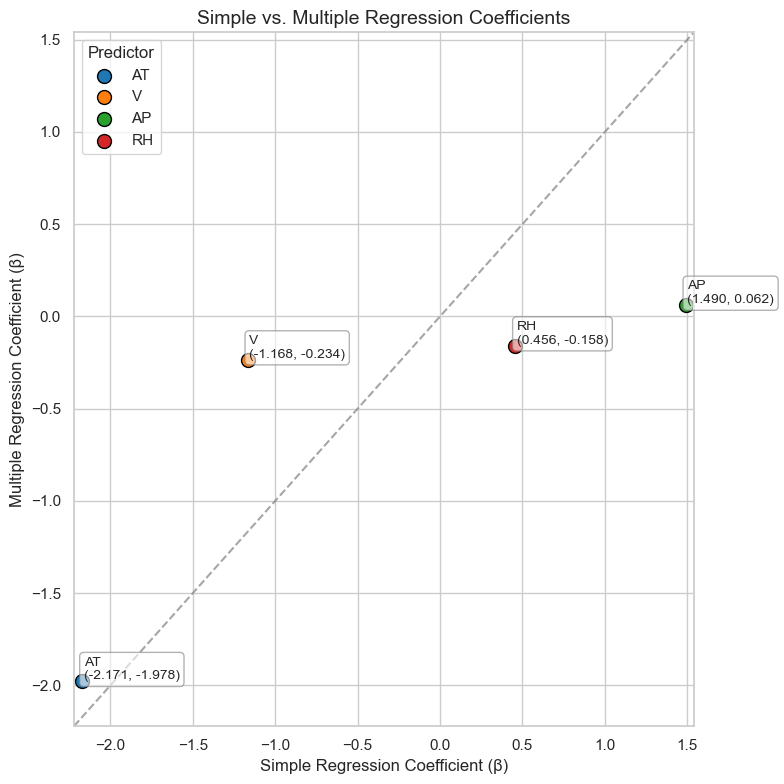

In [13]:
predictors = ['AT', 'V', 'AP', 'RH']    # predictors and response
response = 'PE'

simple_results = {}  # fitting OLS for every predictor
for var in predictors:
    X_simple = sm.add_constant(df[[var]])           # intercept aur predictors ko milaya
    simple_results[var] = sm.OLS(df[response], X_simple).fit()

X_multi = sm.add_constant(df[predictors])           # intercept aur predictors ko milaya
model_multi = sm.OLS(df[response], X_multi).fit()


simple_coef = pd.Series(  # Extract coefficient har ek predictor key liye
    {var: simple_results[var].params[var] for var in predictors},
    name='Simple_Coeff'
)

multi_coef = (
    model_multi.params
               .drop('const')
               .reindex(predictors)
               .rename('Multiple_Coeff')
)


coef_df = pd.concat([simple_coef, multi_coef], axis=1) #ek data frame mai

coef_df['Change'] = np.where(  # arrow wala part
    coef_df['Multiple_Coeff'].abs() > coef_df['Simple_Coeff'].abs(),
    '↑',
    '↓'
)

coef_df[['Simple_Coeff', 'Multiple_Coeff']] = coef_df[['Simple_Coeff', 'Multiple_Coeff']].round(5)

styled_table = ( 
    coef_df[['Simple_Coeff', 'Multiple_Coeff', 'Change']] #  summary table key liye
      .style
      .format({
          'Simple_Coeff': "{:+.3f}",
          'Multiple_Coeff': "{:+.3f}"
      })
      .background_gradient(subset=["Simple_Coeff", "Multiple_Coeff"], cmap="viridis", low=0, high=0.6)
      .set_properties(subset=["Change"], **{"font-weight": "bold", "text-align": "center"})
      .set_table_styles([
          {"selector": "th",
           "props": [("font-size", "12pt"), ("background-color", "#f0f0f0"), ("text-align", "center")]}
      ])
      .set_caption("Comparison: Simple vs. Multiple Regression Coefficients")
)
display(styled_table)

sns.set_style("whitegrid") # scatter of coeff with anno 
plt.figure(figsize=(8, 8))

palette = sns.color_palette("tab10", n_colors=len(predictors))  # har ek predictor ka point plot kiya hai
all_vals = np.concatenate([coef_df['Simple_Coeff'], coef_df['Multiple_Coeff']])
min_val, max_val = all_vals.min() - 0.05, all_vals.max() + 0.05

for idx, var in enumerate(predictors):
    x_val = coef_df.loc[var, 'Simple_Coeff']
    y_val = coef_df.loc[var, 'Multiple_Coeff']
    plt.scatter(
        x_val, y_val,
        s=100,
        color=palette[idx],
        edgecolor='black',
        label=var
    )
    plt.text(
        x_val + 0.01, y_val + 0.01,
        f"{var}\n({x_val:.3f}, {y_val:.3f})",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.6)
    )

plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', color='gray', alpha=0.7) #45-degree wala line
plt.xlabel("Simple Regression Coefficient (β)", fontsize=12)
plt.ylabel("Multiple Regression Coefficient (β)", fontsize=12)
plt.title("Simple vs. Multiple Regression Coefficients", fontsize=14)
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.legend(title="Predictor", loc="upper left")
plt.tight_layout()
plt.show()


***

## 1. (f) Is there evidence of nonlinear association between any of the predictors and the response? To answer this question, for each predictor X, fit a model of the form ##

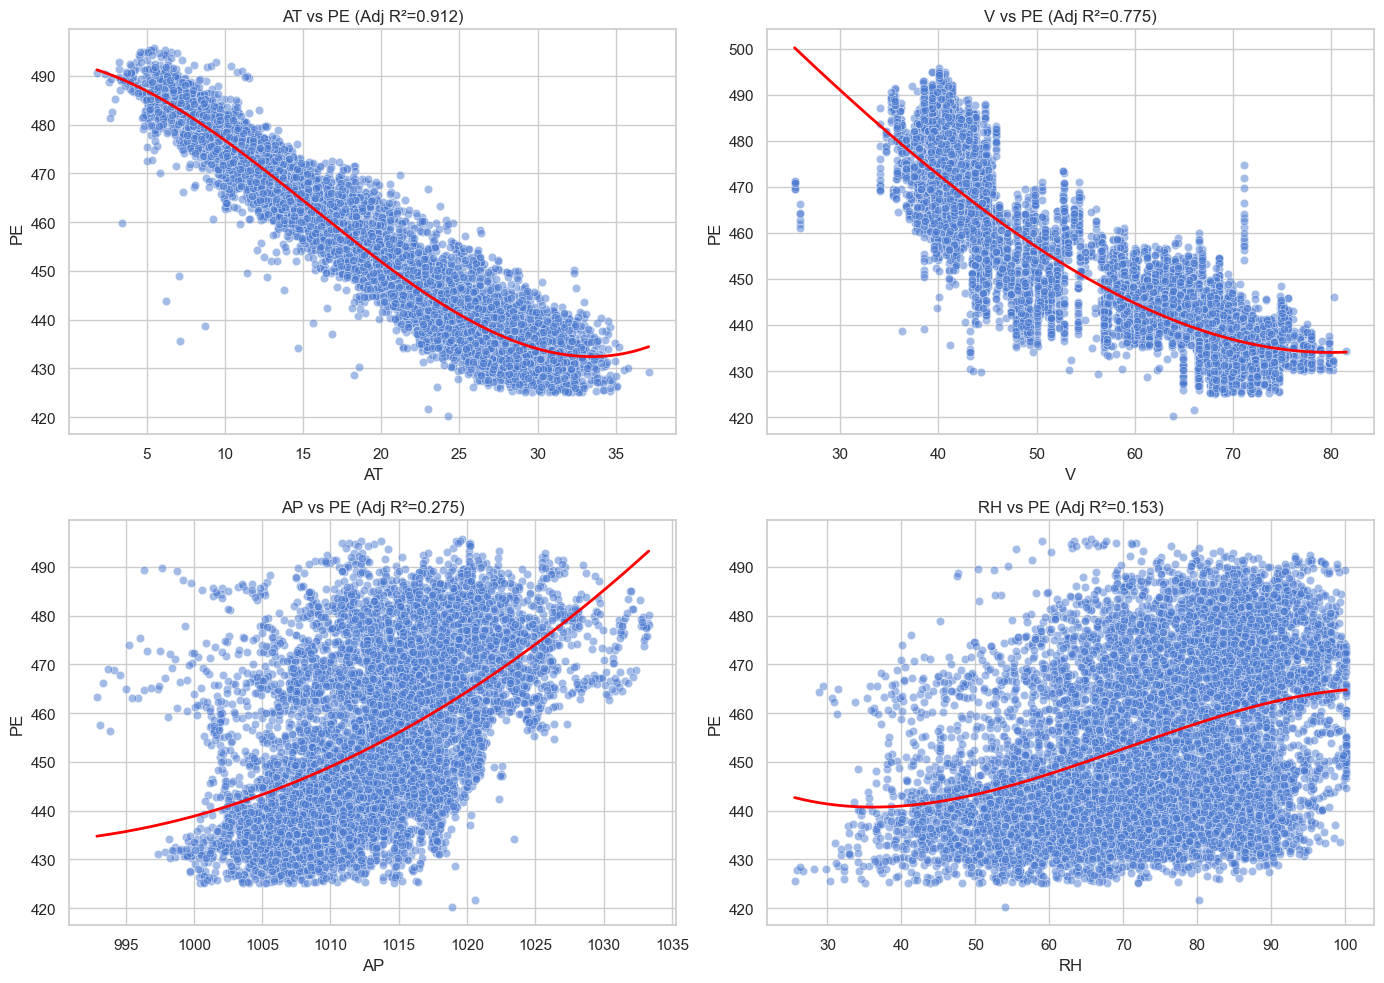


Nonlinear Association Summary:

           Adj. R²  p_linear  p_quadratic  p_cubic
Predictor                                         
AT          0.9119    0.0000       0.0000   0.0000
V           0.7750    0.0000       0.7685   0.0137
AP          0.2747    0.0000       0.0000   0.0000
RH          0.1535    0.0004       0.0000   0.0000


In [14]:
predictors = ['AT', 'V', 'AP', 'RH']
records = []

plt.figure(figsize=(14, 10))
for i, X in enumerate(predictors, start=1):
    # cubic model using formula API
    formula = f"PE ~ {X} + I({X}**2) + I({X}**3)"
    model = smf.ols(formula, data=df).fit()
    
    # Record adjusted R² and p-values for linear, quadratic, and cubic terms
    records.append({
        'Predictor':   X,
        'Adj. R²':     model.rsquared_adj,
        'p_linear':    model.pvalues[X],
        'p_quadratic': model.pvalues[f"I({X} ** 2)"],
        'p_cubic':     model.pvalues[f"I({X} ** 3)"]
    })
    
    # scatter + fitted cubic curve
    ax = plt.subplot(2, 2, i)
    sns.scatterplot(x=df[X], y=df['PE'], alpha=0.5, ax=ax)
    
    # smooth x for curve
    x_seq = np.linspace(df[X].min(), df[X].max(), 200)
    params = model.params
    y_fit = (
        params['Intercept']
        + params[X] * x_seq
        + params[f"I({X} ** 2)"] * x_seq**2
        + params[f"I({X} ** 3)"] * x_seq**3
    )
    ax.plot(x_seq, y_fit, color='red', lw=2)
    ax.set_title(f"{X} vs PE (Adj R²={model.rsquared_adj:.3f})")
    ax.set_xlabel(X)
    ax.set_ylabel("PE")

plt.tight_layout()
plt.show()

# summary table
summary_nonlinear = (
    pd.DataFrame(records)
      .set_index('Predictor')
      .round(4)
)
print("\nNonlinear Association Summary:\n")
print(summary_nonlinear)


* **Ambient Temperature (AT), Ambient Pressure (AP) & Relative Humidity (RH):**
  The cubic terms (x³) all have very small p-values (p ≪ 0.05), demonstrating highly significant non-linear (polynomial) relationships with Energy Output (PE).

* **Exhaust Vacuum (V):**
  The cubic term’s p-value is 0.0137 (still < 0.05), indicating that V also relates to PE via a significant non-linear (cubic) effect.


***

## 1.(g) Is there evidence of association of interactions of predictors with the response? To answer this question, run a full linear regression model with all pairwise interaction terms and state whether any interaction terms are statistically significant. ##

In [15]:
df = df.rename(columns={
    "Ambient Temperature (AT)": "AT",
    "Exhaust Vacuum (V)"       : "V",
    "Ambient Pressure (AP)"    : "AP",
    "Relative Humidity (RH)"   : "RH",
    "Energy Output (PE)"       : "PE"
})

# full pairwise‐interaction model
import statsmodels.formula.api as smf

model_int = smf.ols("PE ~ (AT + V + AP + RH) ** 2", data=df).fit()
print(model_int.summary())

# significant interactions (p < 0.05)
significant_interactions = [
    name for name, p in model_int.pvalues.items()
    if ":" in name and p < 0.05
]

print("\nSignificant interaction terms (p < 0.05):")
for term in significant_interactions:
    print(f"  {term} (p = {model_int.pvalues[term]:.4f})")


                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Mon, 09 Jun 2025   Prob (F-statistic):               0.00
Time:                        23:42:01   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

***

## 1.(h) Can you improve your model ##

In [16]:
#without considering all possible combinations.

df = pd.read_excel(r"../data/CCPP/Folds5x2_pp.xlsx")     
df.columns = df.columns.str.strip()              

train_data, test_data = train_test_split(df, test_size=0.3, random_state=42)
features_list = ['AT', 'V', 'AP', 'RH']
target_var    = 'PE'

mse_scores = {}
model_dict = {}

# Baseline Model (main effects only)
baseline_formula = 'PE ~ ' + ' + '.join(features_list)
baseline_model   = smf.ols(baseline_formula, data=train_data).fit()
model_dict['Baseline'] = baseline_model

train_pred_base = baseline_model.predict(train_data[features_list])
test_pred_base  = baseline_model.predict(test_data[features_list])

mse_scores['Baseline'] = (
    mean_squared_error(train_data[target_var], train_pred_base),
    mean_squared_error(test_data[target_var],  test_pred_base)
)

# Full Enhanced Model (interactions + quadratics)
quad_terms  = ' + '.join([f'I({f}**2)' for f in features_list])
full_formula = f"PE ~ ({' + '.join(features_list)})**2 + {quad_terms}"
full_model   = smf.ols(full_formula, data=train_data).fit()
model_dict['Full Enhanced'] = full_model


train_pred_full = full_model.predict(train_data)
test_pred_full  = full_model.predict(test_data)

mse_scores['Full Enhanced'] = (
    mean_squared_error(train_data[target_var], train_pred_full),
    mean_squared_error(test_data[target_var],  test_pred_full)
)

# Reduced Model (keep only p<0.05 terms)
# dropped Intercept, kept terms with p-value<0.05
sign_terms = full_model.pvalues[full_model.pvalues < 0.05].index.drop('Intercept').tolist()
reduced_formula = 'PE ~ ' + ' + '.join(sign_terms)
reduced_model   = smf.ols(reduced_formula, data=train_data).fit()
model_dict['Reduced'] = reduced_model

train_pred_red = reduced_model.predict(train_data)
test_pred_red  = reduced_model.predict(test_data)

mse_scores['Reduced'] = (
    mean_squared_error(train_data[target_var], train_pred_red),
    mean_squared_error(test_data[target_var],  test_pred_red)
)

mse_df = pd.DataFrame.from_dict(
    mse_scores, orient='index', columns=['Train MSE','Test MSE']
)
print("\nModel MSE Comparison (lower is better):")
print(mse_df.round(3))

# best model on test data
best_name     = mse_df['Test MSE'].idxmin()
best_test_mse = mse_df['Test MSE'].min()
base_test_mse = mse_df.loc['Baseline','Test MSE']
improvement   = (base_test_mse - best_test_mse) / base_test_mse * 100

print(f"\n→ Best performing model on unseen data: **{best_name}**")
print(f"   Test MSE = {best_test_mse:.3f}, which is {improvement:.1f}% lower than Baseline ({base_test_mse:.3f}).")
print("   This shows that adding interaction and quadratic terms, then pruning to significant predictors,")
print("   yields a model with superior out-of-sample accuracy.\n")

#summary of model 
print(f"Detailed summary for **{best_name}**:")
print(model_dict[best_name].summary())



Model MSE Comparison (lower is better):
               Train MSE  Test MSE
Baseline          20.581    21.240
Full Enhanced     17.888    18.647
Reduced           18.457    19.221

→ Best performing model on unseen data: **Full Enhanced**
   Test MSE = 18.647, which is 12.2% lower than Baseline (21.240).
   This shows that adding interaction and quadratic terms, then pruning to significant predictors,
   yields a model with superior out-of-sample accuracy.

Detailed summary for **Full Enhanced**:
                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7272.
Date:                Mon, 09 Jun 2025   Prob (F-statistic):               0.00
Time:                        23:42:02   Log-Likelihood:                -19160.
No. Observations:      

In [17]:
# considering all possible interaction terms instead of pairwise.
df = pd.read_excel(r"../data/CCPP/Folds5x2_pp.xlsx")     
df.columns = df.columns.str.strip() 
train_df, test_df = train_test_split(df, test_size=0.3, random_state=42)

# Baseline: only main effects
base = smf.ols("PE ~ AT + V + AP + RH", data=train_df).fit()
mse_base_train = mean_squared_error(train_df["PE"], base.predict(train_df))
mse_base_test  = mean_squared_error(test_df["PE"],  base.predict(test_df))

# Full: up to 4-way interactions + each X²
quad_terms = " + ".join([f"I({v}**2)" for v in ["AT","V","AP","RH"]])
int_part   = "(" + " + ".join(["AT","V","AP","RH"]) + ")**4"
full = smf.ols(f"PE ~ {int_part} + {quad_terms}", data=train_df).fit()
mse_full_train = mean_squared_error(train_df["PE"], full.predict(train_df))
mse_full_test  = mean_squared_error(test_df["PE"],  full.predict(test_df))


sig = full.pvalues[full.pvalues < 0.05].index.drop("Intercept").tolist()


to_add = []
for term in sig:
    if ":" in term:
        for fac in term.split(":"):
            if fac not in sig:
                to_add.append(fac)
    # for any I(X**2), also keep X
    if term.startswith("I(") and "**2" in term:
        var = term.split("(")[1].split("**")[0]
        if var not in sig:
            to_add.append(var)

sig += to_add
seen, reduced_terms = set(), []
for t in sig:
    if t not in seen:
        seen.add(t)
        reduced_terms.append(t)

red = smf.ols("PE ~ " + " + ".join(reduced_terms), data=train_df).fit()
mse_red_train = mean_squared_error(train_df["PE"], red.predict(train_df))
mse_red_test  = mean_squared_error(test_df["PE"],  red.predict(test_df))


mse_table = pd.DataFrame({
    "Train MSE": [mse_base_train, mse_full_train, mse_red_train],
    "Test  MSE": [mse_base_test,  mse_full_test,  mse_red_test ]
}, index=["Baseline","FullEnhanced","Reduced"]).round(3)

print(mse_table)
print("\nReduced‐model summary:\n", red.summary())


              Train MSE  Test  MSE
Baseline         20.581     21.240
FullEnhanced     17.527     18.217
Reduced          17.528     18.207

Reduced‐model summary:
                             OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.940
Model:                            OLS   Adj. R-squared:                  0.939
Method:                 Least Squares   F-statistic:                     5776.
Date:                Mon, 09 Jun 2025   Prob (F-statistic):               0.00
Time:                        23:42:04   Log-Likelihood:                -19092.
No. Observations:                6697   AIC:                         3.822e+04
Df Residuals:                    6678   BIC:                         3.835e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t  

***

## 1.(i) KNN Regression: ##

### 1.(i). i. Perform k -nearest neighbor regression for this dataset using both normalized and raw features. Find the value of k ∈ { 1 , 2 , . . . , 100 } that gives you the best fit. Plot the train and test errors in terms of 1 /k ###

Clean column names: ['AT', 'V', 'AP', 'RH', 'PE']


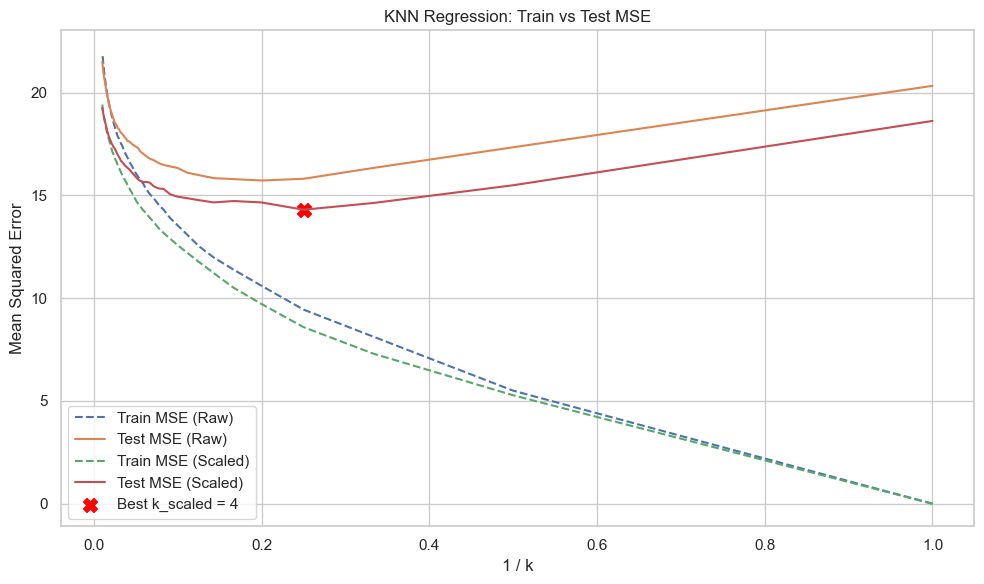

Optimal k (raw):    5 → Test MSE = 15.727
Optimal k (scaled): 4 → Test MSE = 14.306


In [18]:
df = pd.read_excel("../data/CCPP/Folds5x2_pp.xlsx")
df.columns = (
    df.columns
      .str.replace(r'.*\(([^)]+)\).*', r'\1', regex=True)  # keep text inside ( )
      .str.strip()                                          # remove any stray spaces
)

print("Clean column names:", df.columns.tolist())

# Split 70/30
X = df[['AT','V','AP','RH']]
y = df['PE']
Xtr_raw, Xte_raw, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale
scaler = StandardScaler().fit(Xtr_raw)
Xtr_scl = scaler.transform(Xtr_raw)
Xte_scl = scaler.transform(Xte_raw)

# Evaluate KNN for k=1..100
k_vals = np.arange(1,101)
mse_tr_raw, mse_te_raw, mse_tr_scl, mse_te_scl = [], [], [], []

for k in k_vals:
    knn = KNeighborsRegressor(n_neighbors=k)
    # raw
    knn.fit(Xtr_raw, ytr)
    mse_tr_raw.append(mean_squared_error(ytr, knn.predict(Xtr_raw)))
    mse_te_raw.append(mean_squared_error(yte,  knn.predict(Xte_raw)))
    # scaled
    knn.fit(Xtr_scl, ytr)
    mse_tr_scl.append(mean_squared_error(ytr, knn.predict(Xtr_scl)))
    mse_te_scl.append(mean_squared_error(yte,  knn.predict(Xte_scl)))

best_k_raw  = int(np.argmin(mse_te_raw)  + 1)
best_k_scl  = int(np.argmin(mse_te_scl) + 1)

# Plot
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
plt.plot(1/k_vals, mse_tr_raw,  '--', label='Train MSE (Raw)')
plt.plot(1/k_vals, mse_te_raw,   '-',  label='Test MSE (Raw)')
plt.plot(1/k_vals, mse_tr_scl,  '--', label='Train MSE (Scaled)')
plt.plot(1/k_vals, mse_te_scl,   '-',  label='Test MSE (Scaled)')
plt.scatter(1/best_k_scl, mse_te_scl[best_k_scl-1],
            color='red', s=100, marker='X',
            label=f'Best k_scaled = {best_k_scl}')
plt.xlabel('1 / k')
plt.ylabel('Mean Squared Error')
plt.title('KNN Regression: Train vs Test MSE')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal k (raw):    {best_k_raw} → Test MSE = {mse_te_raw[best_k_raw-1]:.3f}")
print(f"Optimal k (scaled): {best_k_scl} → Test MSE = {mse_te_scl[best_k_scl-1]:.3f}")


***

## 1. (j) Compare the results of KNN Regression with the linear regression model that has the smallest test error and provide your analysis ##

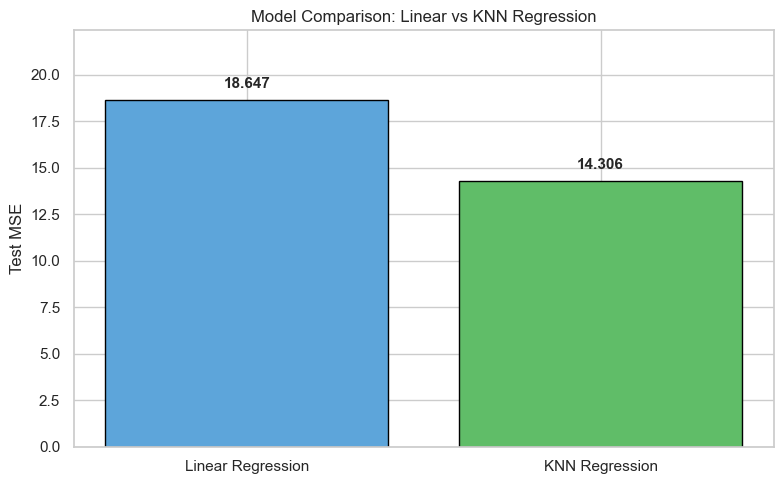

Best linear model: 'Full Enhanced' → Test MSE = 18.647
Best KNN (k=4)   → Test MSE = 14.306

Conclusion: KNN Regression outperforms the linear model on the test set,
indicating that nonlinear/local relationships improve predictive accuracy.


In [19]:
# best linear regression model and its test MSE
best_lin = mse_df['Test MSE'].idxmin()
lin_mse = mse_df.loc[best_lin, 'Test MSE']

# Identify best KNN model (scaled features) and its test MSE
best_k = best_k_scl          
knn_mse = mse_te_scl[best_k - 1]

# Bar chart comparison 
sns.set(style="whitegrid")
plt.figure(figsize=(8, 5))
labels = ['Linear Regression', 'KNN Regression']
values = [lin_mse, knn_mse]
colors = ['#5DA5DA', '#60BD68']            

bars = plt.bar(labels, values, color=colors, edgecolor='black')
plt.ylabel('Test MSE')
plt.title('Model Comparison: Linear vs KNN Regression')

# y-limit
y_max = max(values) * 1.2
plt.ylim(0, y_max)

# bar values
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        h + y_max*0.02,
        f"{h:.3f}",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

# numeric comparison and conclusion
print(f"Best linear model: '{best_lin}' → Test MSE = {lin_mse:.3f}")
print(f"Best KNN (k={best_k})   → Test MSE = {knn_mse:.3f}\n")

if knn_mse < lin_mse:
    print("Conclusion: KNN Regression outperforms the linear model on the test set,")
    print("indicating that nonlinear/local relationships improve predictive accuracy.")
else:
    print("Conclusion: The linear regression model performs as well or better than KNN,")
    print("suggesting the relationship between predictors and response is largely linear.")


***

## 2. ISLR: 2.4.1 ## 
## For each of parts (a) through (d), indicate whether we would generally expect the performance of a fexible statistical learning method to be better or worse than an infexible method. Justify your answer. ##

### a) The sample size n is extremely large, and the number of predictors p is small. ### 

#### When n is extremely large and p is small, a flexible method will generally outperform an inflexible one. With so many observations relative to the number of predictors, the variance of a flexible learner is driven down by the sheer volume of data, allowing it to capture subtle patterns (and even complex relationships) without overfitting, whereas an inflexible method may incur unnecessary bias by imposing too rigid a structure. ####


### b) The number of predictors p is extremely large, and the number of observations n is small. ###

#### When p is extremely large but n is small, an inflexible method is typically superior. In high‐dimensional, low‐sample settings, flexible models suffer from huge variance and tend to overfit noise; by contrast, inflexible approaches (e.g. linear models with few parameters or strong regularization) introduce bias but substantially reduce variance, yielding better generalization on scarce data. ####

### c) The relationship between the predictors and response is highly non-linear. ### 

#### If the true predictor–response relationship is highly non‐linear, flexible methods will almost always win. Inflexible learners (like plain linear regression) carry high bias in the face of curvature or interactions, whereas flexible methods (trees, splines, kernels, neural nets) can adapt to the complexity of the data, dramatically lowering bias and improving predictive accuracy despite somewhat higher variance. #### 

### d) The variance of the error terms, i.e. σ^2 = Var(ϵ), is extremely high. ###

#### When the irreducible error variance σ^2 is extremely high, inflexible methods tend to perform better. In very noisy settings, flexible models chase random fluctuations—driving up variance—while simpler, smoother models ignore much of that noise and offer more stable, lower‐variance predictions, resulting in lower test error overall. ####

- - -

### 3] ISLR: 2.4.7 ###

#### The table below provides a training data set containing six observations, three predictors, and one qualitative response variable. ####
#### Obs.  -  X1  -  X2   -  X3  -  Y ####
####  1   -   0   -   3   -  0   - Red 
####  2   -   2   -   0   -  0   - Red
####  3   -   0   -   1   -  3   - Red
####  4   -   0   -   1   -  2   - Green
####  5   -  −1   -   0   -  1   - Green
####  6   -   1   -   1   -  1   - Red
#### Suppose we wish to use this data set to make a prediction for Y when X1 = X2 = X3 = 0 using K-nearest neighbors. #### 


#### a) Compute the Euclidean distance between each observation and the test point, X1 = X2 = X3 = 0 ####
#### (b) What is our prediction with K = 1? Why? ####
#### (c) What is our prediction with K = 3? Why? ####
#### (d) If the Bayes decision boundary in this problem is highly nonlinear, then would we expect the best value for K to be large or small? Why? ####

In [20]:
from collections import Counter  # Counter for majority voting

data = {
    "Obs": [1, 2, 3, 4, 5, 6],
    "X1":  [ 0,  2,  0,  0, -1,  1],
    "X2":  [ 3,  0,  1,  1,  0,  1],
    "X3":  [ 0,  0,  3,  2,  1,  1],
    "Y":   ["Red", "Red", "Red", "Green", "Green", "Red"]
}
df = pd.DataFrame(data).set_index("Obs")
test_point = np.array([0, 0, 0])

# (a) Euclidean distances to (0,0,0)
df['Distance'] = np.linalg.norm(df[['X1','X2','X3']].values - test_point, axis=1)
print("a) Distances to (0,0,0):")
print(df['Distance'].round(4), "\n")

# (b) K = 1 prediction
k1_idx = df['Distance'].idxmin()
k1_pred = df.loc[k1_idx, 'Y']
print(f"b) K=1 prediction: Obs {k1_idx} is closest → Predict '{k1_pred}'\n")

# (c) K = 3 prediction
k3_idx = df['Distance'].nsmallest(3).index
k3_votes = df.loc[k3_idx, 'Y']
k3_pred = Counter(k3_votes).most_common(1)[0][0]
print(f"c) K=3 neighbors: Obs {list(k3_idx)} with classes {list(k3_votes)}")
print(f"   Majority vote → Predict '{k3_pred}'\n")

# (d) Recommendation for K when decision boundary is highly nonlinear
print("d) If the Bayes boundary is highly nonlinear, choose a small K (e.g., 1 or 3)")



a) Distances to (0,0,0):
Obs
1    3.0000
2    2.0000
3    3.1623
4    2.2361
5    1.4142
6    1.7321
Name: Distance, dtype: float64 

b) K=1 prediction: Obs 5 is closest → Predict 'Green'

c) K=3 neighbors: Obs [5, 6, 2] with classes ['Green', 'Red', 'Red']
   Majority vote → Predict 'Red'

d) If the Bayes boundary is highly nonlinear, choose a small K (e.g., 1 or 3)


---

#### References: ####
1. https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html
2. https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html
3. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html
4. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
5. https://pandas.pydata.org/pandas-docs/stable/reference/frame.html
6.  https://www.statsmodels.org/stable/regression.html



